# Notebook 02 — Model Training
**FracAtlas YOLOv8s Fracture Detection Pipeline**

Trains a YOLOv8s model on the prepared dataset with medical-imaging–optimized
hyperparameters and augmentation strategy.

> **Notebook 01 must be completed successfully before running this notebook.**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports & GPU Check

In [2]:
import os, yaml, torch
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd

# ─── Verify GPU ───────────────────────────────────────────────────────────────
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("VRAM            :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("No GPU detected — training will be slow on CPU.")


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.64 GB


## 1. Configuration

In [3]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
BASE_DIR = Path("/content/FracAtlas")
YAML_PATH = BASE_DIR / "fracatlas_hand_augmented.yaml"
RUNS_DIR  = BASE_DIR / "runs" / "detect"

# ─── MODEL ────────────────────────────────────────────────────────────────────
# yolov8s is the balanced choice for medical imaging with augmented dataset.
# Use 'yolo8n.pt' for quick experiments, 'yolo8l.pt' for max accuracy.
MODEL_WEIGHTS = "yolov8s.pt"   # Will be downloaded automatically if not present
RUN_NAME      = "fracatlas_yolo8s_augmented"

# ─── CORE HYPERPARAMETERS ────────────────────────────────────────────────────
IMGSZ      = 1024     # Keep large — X-rays have fine-detail fractures
EPOCHS     = 100
BATCH_SIZE = 16       # Reduce to 4 if CUDA OOM; increase to 16 if >16 GB VRAM
PATIENCE   = 20       # Early stopping patience (epochs without improvement)
WORKERS    = 4        # DataLoader workers

# ─── MEDICAL-OPTIMISED AUGMENTATION ──────────────────────────────────────────
# Conservative augmentations that respect anatomical structure
AUGMENTATION = dict(
    degrees   = 10.0,   # ±10° rotation — simulates patient positioning
    translate = 0.05,   # Small translation
    scale     = 0.2,    # Mild scale variation
    shear     = 0.0,    # Disabled — distorts anatomy
    perspective = 0.0,  # Disabled — X-rays are projections
    flipud    = 0.0,    # Disabled — anatomical orientation matters
    fliplr    = 0.5,    # OK for symmetric anatomy (arms/legs)
    mosaic    = 0.5,    # Reduced from 1.0 — helps but can create artifacts
    mixup     = 0.1,    # Light mixup
    copy_paste = 0.0,   # Disabled for medical
    hsv_h     = 0.0,    # X-rays are grayscale — no hue shift
    hsv_s     = 0.0,    # No saturation shift
    hsv_v     = 0.2,    # Mild brightness variation (simulate exposure differences)
)

print("- Configuration loaded")
print(f"   Model    : {MODEL_WEIGHTS}")
print(f"   YAML     : {YAML_PATH.resolve()}")
print(f"   Image sz : {IMGSZ}px")
print(f"   Epochs   : {EPOCHS} (patience={PATIENCE})")
print(f"   Batch    : {BATCH_SIZE}")


- Configuration loaded
   Model    : yolov8s.pt
   YAML     : /content/FracAtlas/fracatlas_hand_augmented.yaml
   Image sz : 1024px
   Epochs   : 100 (patience=20)
   Batch    : 16


## 2. Inspect data.yaml

In [4]:
with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)

print("data.yaml contents:")
for k, v in data_cfg.items():
    print(f"  {k}: {v}")

# Quick sanity: check paths resolve
dataset_path = Path(data_cfg["path"])
for split in ["train", "val", "test"]:
    n = len(list((dataset_path / split / "images").iterdir()))
    print(f"  {split}: {n} images")


data.yaml contents:
  path: /content/FracAtlas/yolo_dataset_hand_augmented
  train: images/train
  val: images/val
  test: images/test
  nc: 1
  names: ['fracture']
  train: 2153 images
  val: 461 images
  test: 462 images


## 3. Class Distribution & Final Weighting


In [5]:
# FracAtlas was balanced via undersampling in Notebook 01 (Ratio ~1:2).
# We verify the final distribution and compute weights to guide the model.

label_dir_train = dataset_path / "train" / "labels"
n_frac     = sum(1 for f in label_dir_train.iterdir() if f.stat().st_size > 0)
n_non_frac = sum(1 for f in label_dir_train.iterdir() if f.stat().st_size == 0)
n_total    = n_frac + n_non_frac

# Weight = total / (n_classes * n_samples_for_class)
weight_frac = n_total / (2 * n_frac) if n_frac > 0 else 1.0

print(f"Final Train set distribution:")
print(f"  Fractured    : {n_frac:>5}  ({100*n_frac/n_total:.1f}%)")
print(f"  Non-fractured: {n_non_frac:>5}  ({100*n_non_frac/n_total:.1f}%)")
print(f"  Class weight (fracture): {weight_frac:.2f}")
print()
print("ℹ- We handle the remaining imbalance via:")
print("   1. Undersampling (Done in Notebook 01)")
print("   2. Class weights in loss function (computed above)")
print("   3. Mosaic augmentation (helps model see more fracture examples)")


Final Train set distribution:
  Fractured    :   613  (28.5%)
  Non-fractured:  1540  (71.5%)
  Class weight (fracture): 1.76

ℹ- We handle the remaining imbalance via:
   1. Undersampling (Done in Notebook 01)
   2. Class weights in loss function (computed above)
   3. Mosaic augmentation (helps model see more fracture examples)


## 4. Load Model

In [6]:
# Load pretrained yolov8s backbone (downloads ~40MB if not present)
model = YOLO(MODEL_WEIGHTS)
print(f"- Model loaded: {MODEL_WEIGHTS}")
print(f"   Parameters: {sum(p.numel() for p in model.model.parameters()):,}")


- Model loaded: yolov8s.pt
   Parameters: 11,166,560


## 5. Train

In [7]:
# ─── TRAINING ─────────────────────────────────────────────────────────────────
# All augmentation kwargs are passed directly to model.train()
results = model.train(
    data       = str(YAML_PATH),
    imgsz      = IMGSZ,
    epochs     = EPOCHS,
    batch      = BATCH_SIZE,
    patience   = PATIENCE,
    workers    = WORKERS,
    project    = str(RUNS_DIR),
    name       = RUN_NAME,
    exist_ok   = True,          # Overwrite if rerunning
    pretrained = True,
    optimizer  = "auto",        # Auto-selects SGD or AdamW
    lr0        = 0.01,
    lrf        = 0.01,
    momentum   = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 5,          # Extended warmup for stability
    warmup_momentum = 0.8,
    box        = 7.5,           # Box loss gain
    cls        = 0.5,           # Class loss gain
    dfl        = 1.5,
    # Augmentation
    **AUGMENTATION,
    # Output
    save       = True,
    save_period = 10,           # Save checkpoint every 10 epochs
    plots      = True,
    verbose    = True,
    amp        = True,          # Automatic Mixed Precision (saves VRAM)
    cache      = False,         # Set True if RAM > 32 GB to speed up
    rect       = False,         # Rectangular training — disable for mixed sizes
    cos_lr     = True,          # Cosine LR scheduler
    label_smoothing = 0.1,      # Slight label smoothing helps generalisation
    val        = True,
)

print("\n- Training complete!")
print(f"Best weights saved to: {RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'}")


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/FracAtlas/fracatlas_hand_augmented.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=fracatlas_yolo8s_a

## 6. Plot Training Curves

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


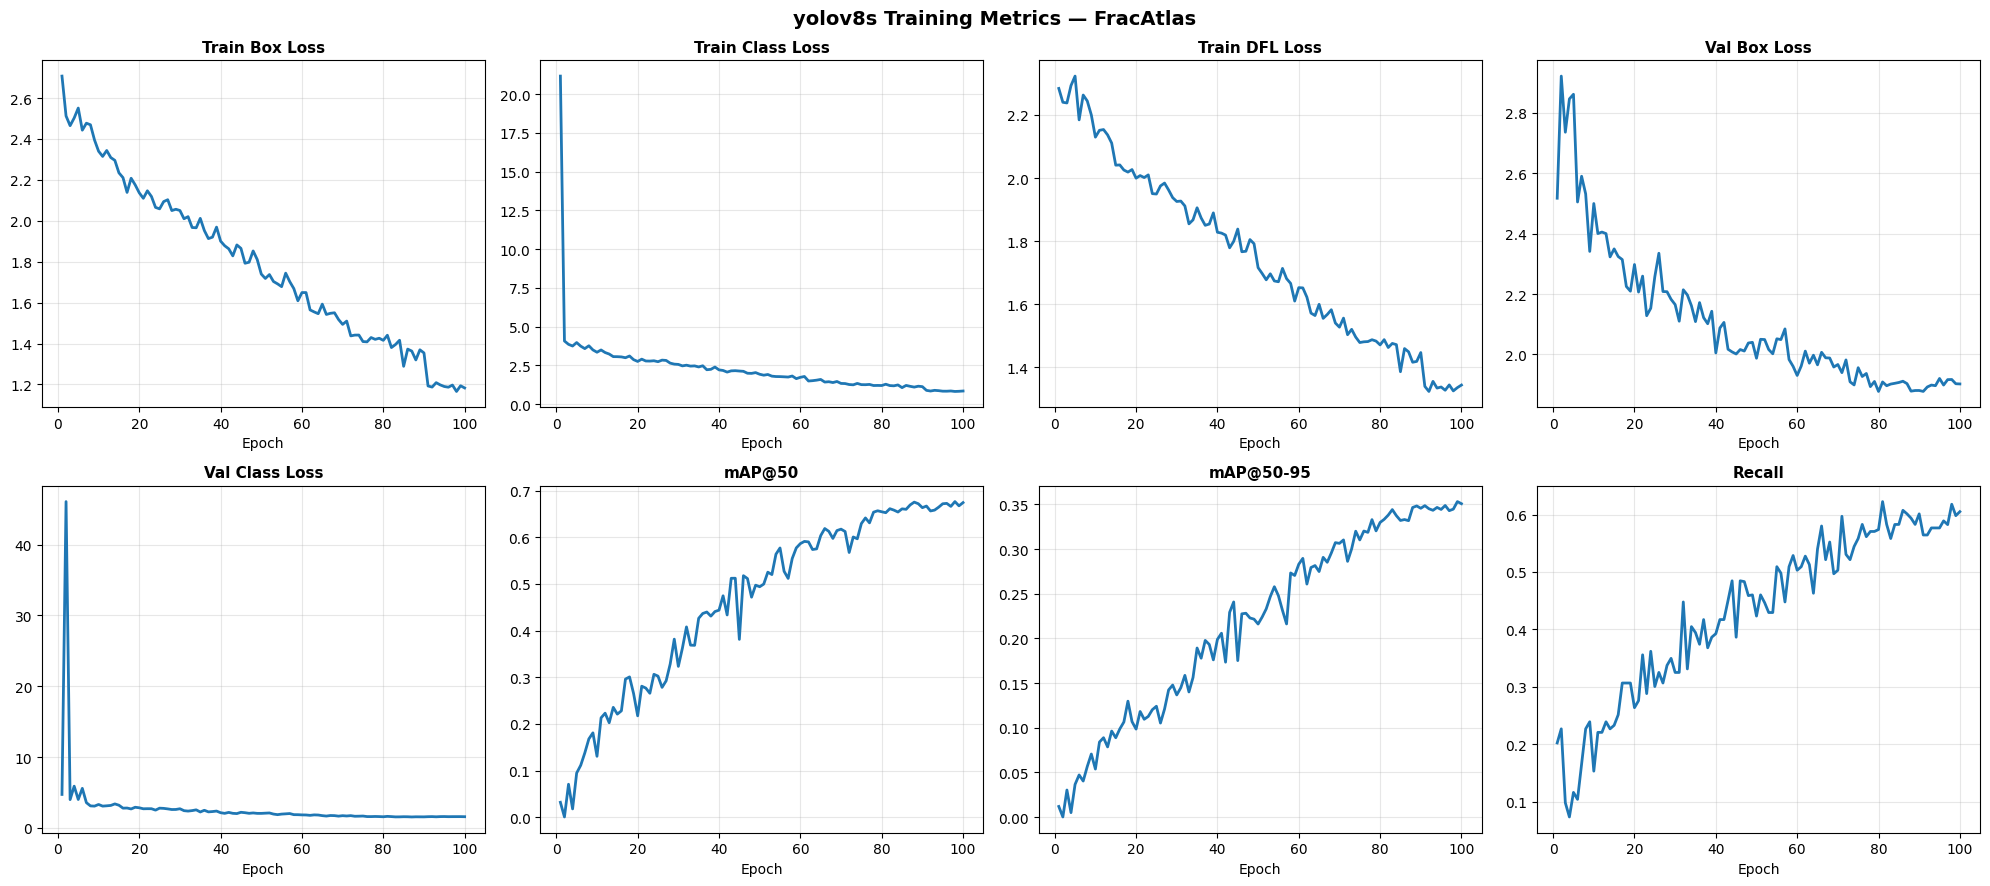

Saved: /content/FracAtlas/training_metrics.png


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

results_csv = RUNS_DIR / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()   # Remove whitespace from col names
    print("Available columns:", df.columns.tolist())

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()

    plot_cols = [
        ("train/box_loss", "Train Box Loss"),
        ("train/cls_loss", "Train Class Loss"),
        ("train/dfl_loss", "Train DFL Loss"),
        ("val/box_loss",   "Val Box Loss"),
        ("val/cls_loss",   "Val Class Loss"),
        ("metrics/mAP50(B)",    "mAP@50"),
        ("metrics/mAP50-95(B)", "mAP@50-95"),
        ("metrics/recall(B)",   "Recall"),
    ]

    for ax, (col, title) in zip(axes, plot_cols):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linewidth=2)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title}\n(column not found)", fontsize=10)
            ax.axis('off')

    plt.suptitle("yolov8s Training Metrics — FracAtlas", fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_path = BASE_DIR / "training_metrics.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")
else:
    print(f"results.csv not found at {results_csv}")


## 7. Best Model Summary

In [ ]:
best_pt = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
last_pt = RUNS_DIR / RUN_NAME / "weights" / "last.pt"

print("=" * 50)
print("  TRAINING SUMMARY")
print("=" * 50)
print(f"Best weights : {best_pt}")
print(f"Last weights : {last_pt}")
print(f"Best exists  : {best_pt.exists()}")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    if "metrics/mAP50(B)" in df.columns:
        best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]
        print(f"\nBest epoch   : {int(best_row['epoch'])}")
        print(f"mAP@50       : {best_row['metrics/mAP50(B)']:.4f}")
        if "metrics/mAP50-95(B)" in df.columns:
            print(f"mAP@50-95    : {best_row['metrics/mAP50-95(B)']:.4f}")
        if "metrics/recall(B)" in df.columns:
            print(f"Recall       : {best_row['metrics/recall(B)']:.4f}")

print("\nProceed to Notebook 03 for evaluation.")
# precision       : {best_row['metrics/precision(B)']:.4f}
# f1-score       : {best_row['metrics/f1_score(B)']:.4f}
# specificity     : {best_row['metrics/specificity(B)']:.4f}

  TRAINING SUMMARY
Best weights : /content/FracAtlas/runs/detect/fracatlas_yolo8s_augmented/weights/best.pt
Last weights : /content/FracAtlas/runs/detect/fracatlas_yolo8s_augmented/weights/last.pt
Best exists  : True

Best epoch   : 98
mAP@50       : 0.6765
mAP@50-95    : 0.3447
Recall       : 0.6179

Proceed to Notebook 03 for evaluation.


In [13]:
!zip -r /content/hasil_training_hand_augmented.zip /content/FracAtlas/

Streaming output truncated to the last 5000 lines.
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0000600.txt (deflated 23%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0003999_aug0.txt (stored 0%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0000237.txt (stored 0%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0004201_aug0.txt (stored 0%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0004045_aug0.txt (deflated 10%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0004243_aug0.txt (stored 0%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0001997_aug0.txt (stored 0%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0002569_aug0.txt (deflated 27%)
updating: content/FracAtlas/yolo_dataset_hand_augmented/labels/train/IMG0002354_aug0.txt (deflated 12%)
updating: content/FracAtlas/yolo_datas

In [14]:
import shutil

# Tentukan lokasi tujuan di Drive Anda
# Pastikan folder 'Project Medical Object Detection' sudah ada di Drive
drive_path = "/content/drive/MyDrive/Backup Colab/FracAtlas"

# Buat folder tujuan jika belum ada
!mkdir -p "{drive_path}"

# Salin file zip ke Drive
!cp /content/hasil_training_hand_augmented.zip "{drive_path}"

print(f"File berhasil disimpan ke: {drive_path}")


File berhasil disimpan ke: /content/drive/MyDrive/Backup Colab/FracAtlas
